In [1]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt
# from tda_methods import LSTMAutoencoder, GeometryConverter, PersistencePlotter, TakensEmbedding, WassersteinDistance, \
#             plot_3d_points, numpy_to_torch, window_2d_sequence_to_3d, write_results_to_file, \
#             plot_all_features_in_2d_array, plot_latent_evolution_grid, read_yaml_params
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
# from torch import nn
# from torch.utils.data import DataLoader, TensorDataset
from torch_cluster import radius_graph

# from pathlib import Path
from typing import Optional
import seaborn as sns

# import gudhi
# import cProfile

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
"main persistence code"

def generate_torus_point_cloud(n_points: int = 2000, R_major: float = 1.0, r_minor: float = 0.3,
                                          noise: float = 0.01, rand_seed: Optional[int] = None,
                                          device = device, dtype: torch.dtype = torch.float32) -> torch.Tensor:
    """Generate a 2D torus-like (ring) point cloud on GPU using PyTorch.
    n_points = #points to generate
    rand_seed = random seed for reproducibility
    R_major/r_minor are the major/minor radii of the torus. Noise is added to r_minor"""

    if rand_seed is not None:
        torch.manual_seed(rand_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(rand_seed)

    theta  = torch.rand(n_points, device=device, dtype=dtype) * (2 * torch.pi)
    radial = R_major + r_minor * torch.randn(n_points, device=device, dtype=dtype)
    x      = radial * torch.cos(theta)
    y      = radial * torch.sin(theta)
    pts    = torch.stack([x, y], dim=1)
    pts    = pts + noise * torch.randn_like(pts)
    return pts

# to remove, edge_index is more efficient
def adjacency_from_distance_matrix(D: torch.Tensor, epsilon: float) -> torch.Tensor:
    """Given distance matrix D and threshold epsilon, find which node pairs are connected
    Output: binary (bool) adjacency matrix from distance matrix. No self-edges"""
    A = (D < epsilon) & (D > 0.0) # keep distances < epsilon, and remove self-edges (D=0)
    A = torch.triu(A, diagonal=1) # take upper triangle + remove diagonal
    A = A | A.T                   # applies upper triangle to lower part to make symmetric (without diagonal)
    return A

def count_edges(A: torch.Tensor) -> int:
    """Count undirected edges from upper (or lower) triangle"""
    return int(torch.triu(A, diagonal=1).sum().item())

def count_triangles_from_adjacency(A: torch.Tensor) -> int:
    """Count undirected triangles using spectral triangle counting.
    uses matrix trace identity: # triangles = trace(A^3)/6
    - each triangle appears 6 times"""
    Af = A.float()
    A3 = Af @ Af @ Af # compute A^3 (counts length-3 walks between nodes)
    return int(torch.trace(A3).item() / 6) # Trace gives total closed 3-walks; divide by 6 to correct overcounting

class UnionFind:
    """Union-find / disjoint set."""
    def __init__(self, n: int):
        self.parent = torch.arange(n, device=device)
        self.rank = torch.zeros(n, dtype=torch.int32, device=device)

    def find(self, x: int) -> int:
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return int(x)

    def union(self, x: int, y: int):
        rx, ry = self.find(x), self.find(y)
        if rx == ry:
            return

        if self.rank[rx] < self.rank[ry]:
            self.parent[rx] = ry
        elif self.rank[rx] > self.rank[ry]:
            self.parent[ry] = rx
        else:
            self.parent[ry] = rx
            self.rank[rx] += 1

    def num_components(self) -> int:
        # roots = torch.unique(self.parent)
        roots = set(self.find(int(i)) for i in range(len(self.parent)))
        return len(roots)

class BettiComputer:
    def __init__(self, n_triangles, n_edges, n_vertices, device=device):
        self.n_triangles = n_triangles
        self.n_edges     = n_edges
        self.n_vertices  = n_vertices
        self.device      = device

    def compute_betti_0(self, adj: torch.Tensor, tolerance: float = 1e-5) -> int:
        """Connected components via Laplacian spectrum. Betti-0 via graph Laplacian.. B0 = vertices - rank."""
        A       = adj.float()
        degree  = torch.diag(A.sum(dim=1))
        L       = degree - A
        eigvals = torch.linalg.eigvalsh(L)
        return int((eigvals < tolerance).sum().item())

    def compute_betti_0_edge_index(self, edge_index: torch.Tensor, n_vertices: int) -> int:
        """Connected components via union-find."""
        uf       = UnionFind(n_vertices)
        src, dst = edge_index
        for i in range(src.numel()):
            uf.union(int(src[i]), int(dst[i]))
        self.B0 = uf.num_components()
        return self.B0

    def compute_betti_1(self, V: int, E: int, B0: int) -> int:
        """Betti B1 = edges + connected components - vertices
        connected components C = B0, which are the # of unique clusters of points"""
        return max(E + B0 - V, 0)


In [ ]:
"computations"
n_points     = 100
point_cloud  = generate_torus_point_cloud(n_points, R_major=1.0, r_minor=0.10, noise=0.005, rand_seed=4, device=device)

start_time = time.time()

D        = torch.cdist(point_cloud, point_cloud)
max_dist = D.max().item()
D        = D / max_dist # normalize to [0,1], better numerical stability

# ~~~~~~~~~~~~~~~~~~~~~
src, dst = torch.triu_indices(n_points, n_points, offset=1, device=device)
weights  = D[src, dst]
perm     = torch.argsort(weights)
src      = src[perm]
dst      = dst[perm]
weights  = weights[perm]
uf = UnionFind(n_points)

B0_arr = []
B1_arr = []

E = 0
for i in range(len(weights)):
    u = int(src[i])
    v = int(dst[i])

    uf.union(u, v)
    if uf.find(u) != uf.find(v):
        print(f"merge at eps={weights[i].item():.3f}")
    E += 1
    B0 = uf.num_components()
    B1 = E - n_points + B0

    if i % 500 == 0:
        print(
            f"step={i}/{len(weights)} | "
            f"eps={weights[i].item():.4f} | "
            f"E={E} | B0={B0} | B1={B1}")
    B0_arr.append(B0)
    B1_arr.append(B1)

# ~~~~~~~~~~~~~~~~~~~~~
# B0_arr, B1_arr = [], []
# betti_obj = BettiComputer(n_triangles=0, n_edges=0, n_vertices=n_points, device=device)

# counter= 0
# eps    = 0
# step   = 0.05

# while eps <= max_dist:
#     adj         = adjacency_from_distance_matrix(D, eps)
#     n_edges     = count_edges(adj)
#     n_triangles = count_triangles_from_adjacency(adj)
    
#     edge_index = radius_graph(point_cloud, r=eps, loop=False)
#     # B0 = betti_obj.compute_betti_0(adj, tolerance=1e-5)
#     B0 = betti_obj.compute_betti_0_edge_index(edge_index, n_vertices=n_points)
#     E  = edge_index.shape[1]
#     B1 = betti_obj.compute_betti_1(V=n_points, E=E, B0=B0)
#     B0_arr.append(B0)
#     B1_arr.append(B1)

#     density = E / (n_points * (n_points - 1) // 2)

#     if (counter + 1) % 5 == 0:
#         print(f"eps={eps:.2f}/{max_dist:.2f} | "
#             f"edges={n_edges}/{n_points*(n_points-1)//2} | "
#             f"triangles={n_triangles}/{math.comb(n_points, 3)} | "
#             f"Betti: B0={B0}, B1={B1} | "
#             f"Density: {density:.4f}")
#     eps += step
#     counter += 1
# # ~~~~~~~~~~~~~~~~~~~~~

end_time = time.time()
print(f"⚠️ Operations completed in {end_time - start_time:.4f} seconds")

plt.figure()
plt.plot(np.arange(len(B0_arr)) * step, np.log(B0_arr), label='log(B0)')
plt.plot(np.arange(len(B1_arr)) * step, np.log(B1_arr), label='log(B1)')
plt.legend()
plt.show()

# ===============
plt.scatter(point_cloud[:, 0].cpu(), point_cloud[:, 1].cpu(), s=2)
plt.gca().set_aspect('equal')
plt.show()
plt.figure()
sns.heatmap(D.cpu(), cmap='viridis')
plt.title("Distance matrix")


In [ ]:
M       = np.array([[0, 1, 0, 1, 1, 0],
                    [1, 0, 0, 0, 1, 0],
                    [0, 0, 0, 0, 0, 0],
                    [1, 0, 0, 0, 0, 1],
                    [1, 1, 0, 0, 0, 1],
                    [0, 0, 0, 1, 1, 0]])
M_bool  = M.astype(bool)
M2      = M@M # number of shared friends
M2_bool = (M2 > 0)

triangles = M2_bool & M_bool  # shared friend AND direct edge
np.fill_diagonal(triangles, False)  # ignore diagonal

print("M2:\n", M2)
print("Triangles matrix:\n", triangles)

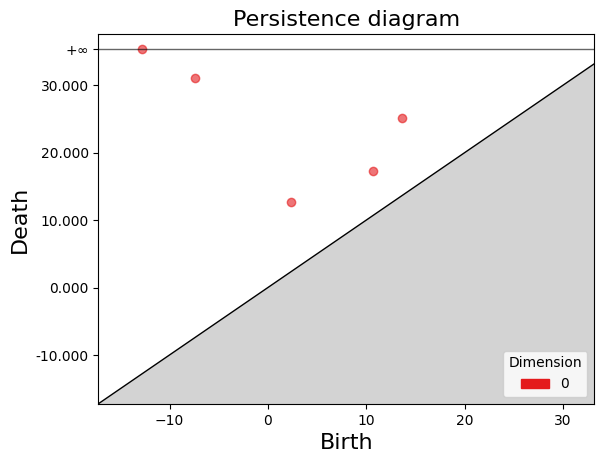

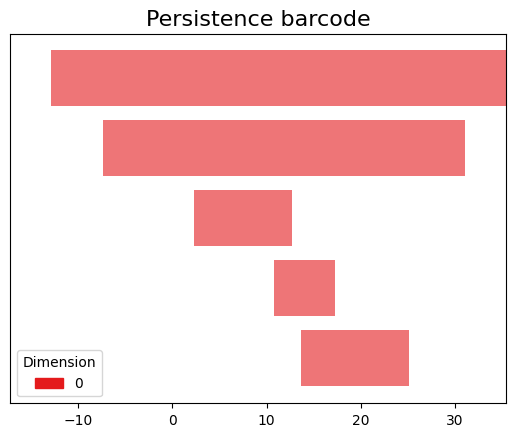

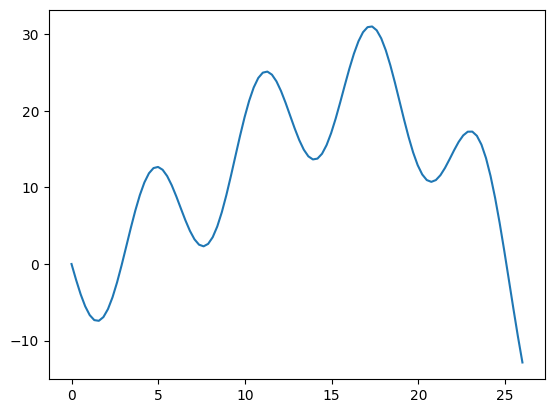

In [60]:
import matplotlib
matplotlib.rcParams['text.usetex'] = False
import gudhi
from gudhi import CubicalComplex

start_point, end_point = 0, 26
num_timesteps = 100
x      = torch.linspace(start_point, end_point, num_timesteps)
signal = -0.01*x**3+0.25*x**2 -8*torch.sin(x) #1.8*x**3 + 3*x**2 + 8*x - 0.5*x**4 +0.02*x**5 #+torch.sin(x) #.1*x + torch.sin(x) + torch.sin(0.1 * x**2)

cc = CubicalComplex(dimensions=signal.shape, top_dimensional_cells=signal.numpy().flatten())
cc.compute_persistence()
pairs = cc.persistence()  # (dimension, (birth, death))

gudhi.plot_persistence_diagram(cc.persistence())
gudhi.plot_persistence_barcode(cc.persistence())

plt.figure()
plt.plot(x.numpy(), signal.numpy())
plt.show()
